In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt
import math

from model.classifier import Classifier, MyProgressBar
from model.spatial_transformer_classifier import SpatialTransformerClassifier  # Import spatial transformer classifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.set_float32_matmul_precision('high')

In [3]:
from utils.transform_sequence import TransformSequence,create_sampler
from utils.transforms.apply import grid_resample
from utils.affine_transforms import AffineTransformation2D


transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]

transformations2 = [AffineTransformation2D.ROTATION_COMPLEX.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]

domains1 = [(-math.pi,math.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]

domains2 = [(-1.0,1.0), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17

transform_seq= TransformSequence(transformations, domains1, neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=True,use_individual_param_correction=False)

transform_seq2= TransformSequence(transformations2, domains2, neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=True,use_individual_param_correction=False)

sampler = create_sampler(transform_seq)

In [4]:
from its.transform import multi_transform
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.






dataset_test = AffineTransformDataset(dataset_test_pre,sampler,return_transformation=False,batch_size=batch_size)


# Create transformed datasets for both training and testing
dataset_train_transformed = AffineTransformDataset(dataset_train, sampler, return_transformation=False, batch_size=batch_size)


In [5]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)

# Create data loader for transformed training data
train_transformed_loader = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)


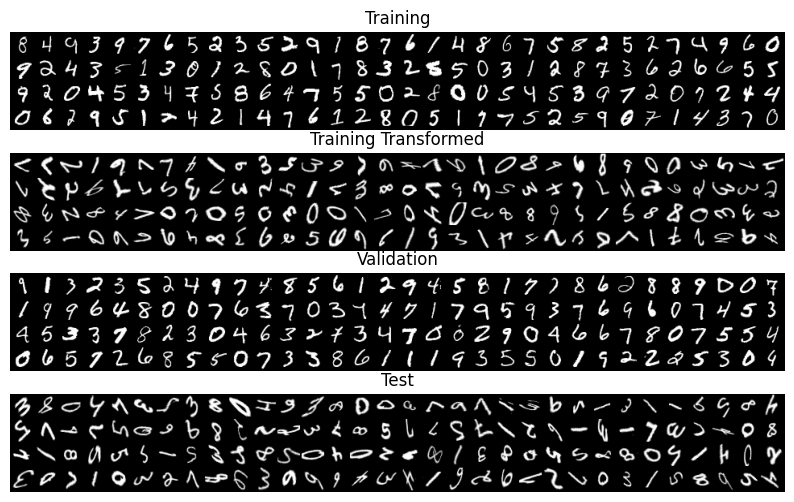

In [6]:
#test images
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10, 6))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(train_transformed_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[3].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Training Transformed')
axs[2].set_title('Validation')
axs[3].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [7]:
import pytorch_lightning as pl
import os

model_path = f'../model/{dataset}_23.pth'

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


Loading model from ../model/mnist_23.pth


In [8]:
# Define localization network for spatial transformer
localization_net = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.GELU(),

)

# Calculate the output dimension of the localization network
with torch.no_grad():
    dummy_input = torch.zeros(1, 1, 28, 28)
    loc_output = localization_net(dummy_input)
    localization_dim = loc_output.numel()  # Get the flattened size
    print(f"Localization network output dimension: {localization_dim}")

# Create spatial transformer model (6 parameters for 2D affine transformation)
spatial_model_path = f'../model/{dataset}_spatial_transformer.pth'

Localization network output dimension: 128


In [9]:
from utils.transformation_problem import TransformationProblem



# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq2),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq2),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 1e-3},
        optimizer_class = torch.optim.Adam,
        train_noise_scale = 0.01
    )

    # Train the spatial transformer model on transformed data
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[MyProgressBar()]
    )
    trainer.fit(spatial_transformer, train_transformed_loader, test_loader)

    # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")


Loading spatial transformer model from ../model/mnist_spatial_transformer.pth


from utils.transformation_problem import TransformationProblem
#this had lower performance than the previos parameterization. Direct directly calculates the values of matrix entries.
spatial_model_path2 = f'../model/{dataset}_spatial_transforme2r.pth'

transformations3 = [AffineTransformation2D.DIRECT.value]
domains3 = [(-2,2)]
transform_seq3 = TransformSequence(transformations3,domains3)



# Check if spatial transformer model exists
if os.path.exists(spatial_model_path2) and True:
    print(f"Loading spatial transformer model from {spatial_model_path2}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq3),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True  # Freeze the base model
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path2))
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path2}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq3),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 1e-3},
        optimizer_class = torch.optim.Adam,
        train_noise_scale = 0.00,
        l2_weight=0.01
    )

    # Train the spatial transformer model on transformed data
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[MyProgressBar()]
    )
    trainer.fit(spatial_transformer, train_transformed_loader, test_loader)

    # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path2)
    print(f"Spatial transformer model saved to {spatial_model_path2}")


In [10]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [11]:
model.cuda()
spatial_transformer.cuda()

SpatialTransformerClassifier(
  (main_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=3136, out_features=128, bias=True)
    (10): Dropout(p=0.5, inplace=False)
    (11): GELU(approximate='none')
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
  (localization_net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate

In [12]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.9908.


In [13]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    model.eval()
    base_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        base_acc += output.argmax(dim=-1).eq(target).sum().item()
    base_acc /= len(dataset_test)
    print(f'Base model accuracy on the transformed test set: {base_acc}.')

    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer(data)
        st_acc += output.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

Base model accuracy on the transformed test set: 0.3972.
Spatial transformer accuracy on the transformed test set: 0.8936.


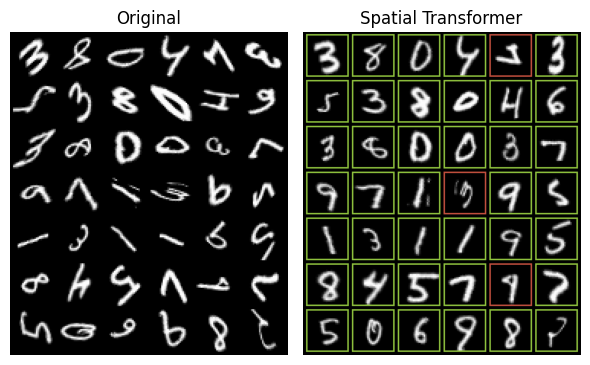

In [14]:
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(test_loader))
    data, target = data.cuda()[:42], target.cuda()[:42]


    # 2. Apply spatial transformer
    transformed = spatial_transformer.transform_input(data)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red   = torch.tensor((194,  80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:,   0, :] = color
        img[:,  -1, :] = color
        img[:, :,   0] = color
        img[:, :,  -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(6, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=6).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=6).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [15]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'10',flatten=True)

In [16]:
dual_ouput_model.eval().cuda()

ModelInputWrapper(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=3136, out_features=128, bias=True)
    (10): Dropout(p=0.5, inplace=False)
    (11): GELU(approximate='none')
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [17]:
#extract embeddings and fit NNDistanceConfidence()
embeddings=[]
classes =[]
from confidence.direct.logit_based import EnergyConfidence
energy_conf_module = EnergyConfidence()

logits = []

for batch in train_loader:
    emb,logit = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())
    logits.append(logit.detach().cpu().numpy())


embeddings = np.vstack(embeddings)
classes = np.hstack(classes)
logits = np.vstack(logits)
#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings_sampled = embeddings[indices]
    classes_sampled = classes[indices]
    logits_sampled = logits[indices]
else:
    embeddings_sampled = embeddings
    classes_sampled = classes
    logits_sampled = logits


In [18]:
import search.shgo
di = search.shgo.SHGO(selection_method="topk")


In [19]:
from confidence.control.split import SplitConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.model.single_pass import SinglePassConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence



In [20]:
nearest_neighbor_confidence = KNNConfidence(k=5,metric="cosine")
nearest_neighbor_confidence.fit(embeddings)
nearest_neighbor_confidence.cuda()


conf_split = SplitConfidence(nearest_neighbor_confidence, EnergyConfidence(), mult=False, b=0.0)
conf_2 = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem = TransformationProblem(conf_2, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9498.


In [21]:

nn_pytorch = KNNConfidence(metric="cosine",k=5)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu())
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9386.


In [22]:
#rotate a single image to an orbit

In [78]:
random_untransformed = next(iter(train_loader))[0][[5]].to(device)
transform_rotate = AffineTransformation2D.ROTATION.value
param = torch.arange(-torch.pi, torch.pi, 2 * torch.pi / 16).unsqueeze(1).to(device)  # rotation parameters
param.cpu()
from utils.transforms.apply import grid_resample

ts = transform_rotate(param).to(device)
x_transformed = grid_resample(random_untransformed.repeat(len(param), 1, 1, 1), ts)
#calculate the confidnces
x_conf = conf_mod_nn_pytorch(x_transformed)[0]

highest_conf_index = x_conf.argmax()

#add red border to middle image with param equal to 0
x_transformed = x_transformed.repeat(1, 3, 1, 1)  # repeat the image
x_transformed[highest_conf_index, 0, :, 0] = 1  # set the red channel to 1
x_transformed[highest_conf_index, 1, :, 0] = 0  # set the green channel to 0
x_transformed[highest_conf_index, 2, :, 0] = 0  # set the blue channel to 0
#second border
x_transformed[highest_conf_index, 0, :, -1] = 1  # set the red channel to 1
x_transformed[highest_conf_index, 1, :, -1] = 0  # set the green channel to 0
x_transformed[highest_conf_index, 2, :, -1] = 0  # set the blue channel to

x_transformed[highest_conf_index, 0, 0, :] = 1  # set the
x_transformed[highest_conf_index, 1, 0, :] = 0  # set the green channel to 0
x_transformed[highest_conf_index, 2, 0, :] = 0  # set the blue channel to 0

x_transformed[highest_conf_index, 0, -1, :] = 1  # set the red channel to 1
x_transformed[highest_conf_index, 1, -1, :] = 0  # set the green channel to 0
x_transformed[highest_conf_index, 2, -1, :] = 0  # set the blue channel to 0

(-0.5, 241.5, 61.5, -0.5)

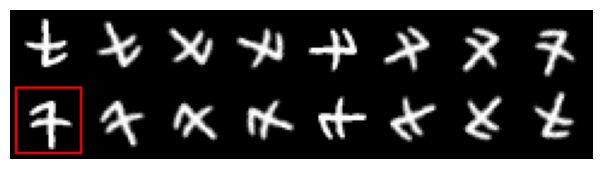

In [79]:
plt.imshow(torchvision.utils.make_grid(x_transformed, nrow=8).permute(1, 2, 0).cpu())
#set tight layout()
plt.tight_layout()
#disable axis
plt.axis('off')
#remove white border


Best image index: 8, confidence: 0.9536


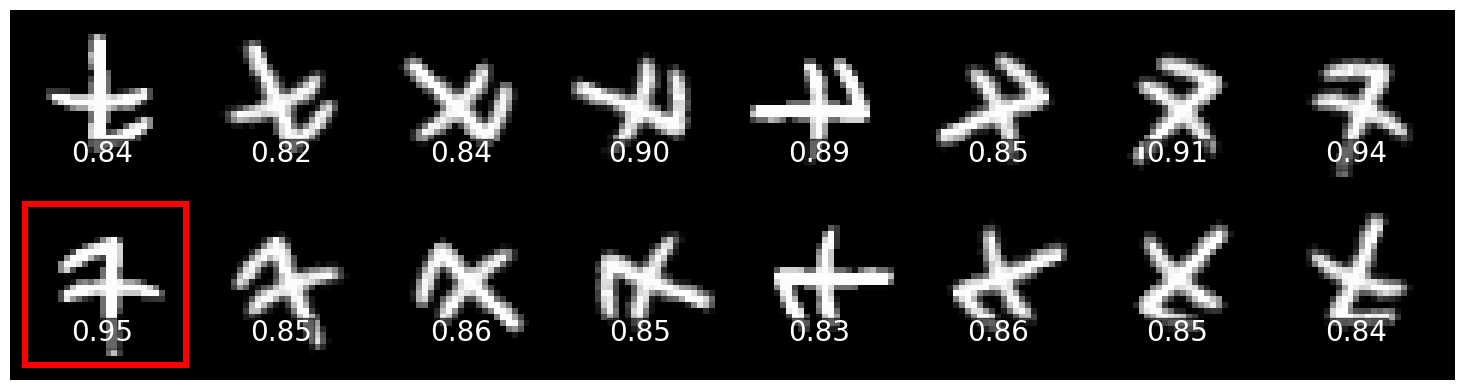

In [81]:
import torch
import matplotlib.pyplot as plt
import torchvision
import numpy as np

# --- after: x_conf = conf_mod_nn_pytorch(x_transformed) ---

# If x_conf is [batch] already, conf_vals = x_conf.
# If it's [batch, classes], take the max over classes.
if x_conf.dim() == 1:
    conf_vals = x_conf
else:
    # this branch only if you really do have a second dim
    conf_vals, _ = x_conf.max(dim=1)

# Now conf_vals is [batch]
highest_conf_index = conf_vals.argmax(dim=0).item()

print(f"Best image index: {highest_conf_index}, confidence: {conf_vals[highest_conf_index].item():.4f}")

# --- (optional) add red border to the best image as you had before ---
# ... your border‑drawing code on x_transformed[highest_conf_index] ...

# Plot grid with confidence labels
fig, ax = plt.subplots(figsize=(16, 4))
grid_img = torchvision.utils.make_grid(x_transformed, nrow=8, padding=2)
npimg = grid_img.permute(1, 2, 0).cpu().numpy()
ax.imshow(npimg)
ax.axis('off')

# compute spacing (image height + padding)
img_h = x_transformed.shape[2] + 2
img_w = x_transformed.shape[3] + 2
ncols = 8

for idx, conf in enumerate(conf_vals):
    row = idx // ncols
    col = idx % ncols
    x = col * img_w + img_w // 2
    y = row * img_h + img_h - 4
    ax.text(
        x, y,
        f'{conf.item():.2f}',
        color='white', fontsize=20, ha='center', va='bottom',
        bbox=dict(facecolor='black', alpha=0.6, pad=1)
    )

plt.tight_layout()
plt.show()


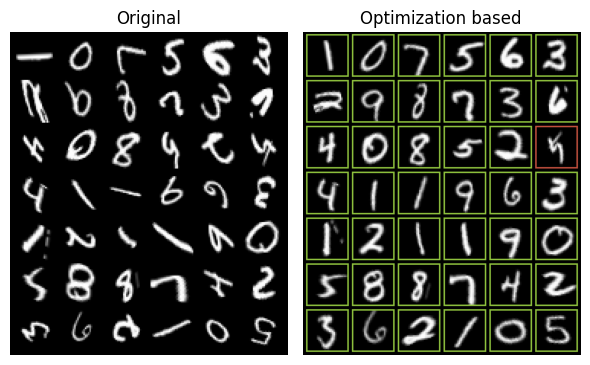

In [22]:
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(test_loader))
    data, target = data.cuda()[:42], target.cuda()[:42]
    res = di.optimize(problem, data.cuda())[0]



    # 2. Apply spatial transformer
    transformed = transform_seq.transform(data,res)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red   = torch.tensor((194,  80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:,   0, :] = color
        img[:,  -1, :] = color
        img[:, :,   0] = color
        img[:, :,  -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(6, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=6).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=6).permute(1, 2, 0))
    axs[1].set_title('Optimization based')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [23]:
from confidence.input_transform import InputTransform

input_transform = InputTransform(standardize=True)
input_transform.fit(torch.tensor(embeddings).cuda())

In [24]:


encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()

In [28]:

from confidence.direct.targeted import CrossEntropyConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nearest_neighbor_confidence2 = PerClassKNNConfidence(metric="cosine",k=5,input_transform=input_transform)
nearest_neighbor_confidence2.fit(torch.tensor(embeddings_sampled).cuda(),torch.tensor(classes_sampled).cuda())
nearest_neighbor_confidence2.cuda()
conf_split_guided = SplitConfidence(nearest_neighbor_confidence2, CrossEntropyConfidence(), mult=True,a=1.0)

In [29]:


conf_guided = SinglePassConfidence(dual_ouput_model, conf_split_guided,index=1)
problem_guided = TransformationProblem(conf_guided, transform_seq, consolidate_method="consolidate_simple")

problem_unguided = problem


In [30]:
import search.shgo
import importlib

importlib.reload(search.shgo)
di = search.shgo.SHGO(selection_method="topk")
test_acc_sim = 0
stop_at = 1
counter = 0
regression_data = []
regression_target =[]

for d, (data, target) in enumerate(train_transformed_loader):
    data, target = data.cuda(), target.cuda()
    regression_data.append(data.detach().cpu().numpy())
    res = di.optimize(problem_guided, data.cuda(),y=target.cuda())
    regression_target.append(res[0].detach().cpu().numpy())

    # Apply the transformation and get predictions
    x_transformed2 = problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
    print(d)

test_acc_sim /= counter

print(f'With class knowledge we can define a canonical represenation of the data: {test_acc_sim}.')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [31]:

import search.shgo
import importlib

importlib.reload(search.shgo)
di = search.shgo.SHGO(selection_method="topk")
test_acc_sim = 0
stop_at = 1
counter = 0


for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_unguided, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
    print(d)

test_acc_sim /= counter

print(f'With class knowledge we can define a canonical represenation of the data: {test_acc_sim}.')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
With class knowledge we can define a canonical represenation of the data: 0.9484.


In [32]:

class RegressionDataset(torch.utils.data.Dataset):

    def __init__(self, data, target_params):
        self.data = data
        self.target_params = target_params

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        target_params = self.target_params[idx]
        return x, target_params


In [33]:
regression_target = np.vstack(regression_target)
regression_target = torch.tensor(regression_target, dtype=torch.float32).cpu()
regression_data = np.vstack(regression_data)
regression_data = torch.tensor(regression_data, dtype=torch.float32).cpu()
regression_dataset = RegressionDataset(regression_data, regression_target)
regression_dataloader = torch.utils.data.DataLoader(regression_dataset, batch_size=batch_size, shuffle=True, num_workers=0)


(-0.5, 301.5, 301.5, -0.5)

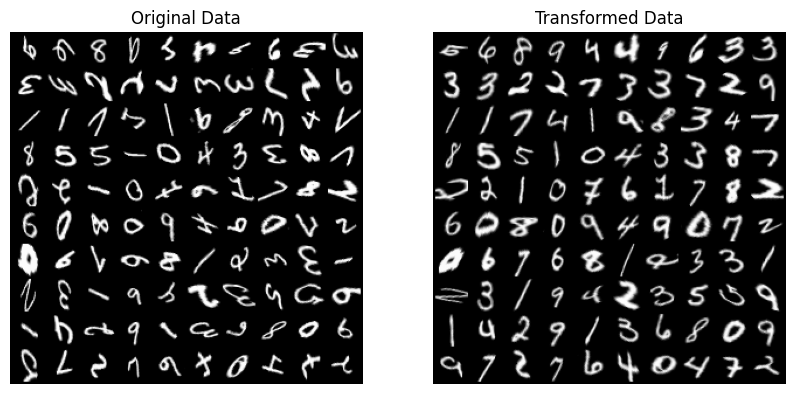

In [34]:
#plot dataset and transformed dataset sample

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
x,p = regression_dataset[:100]

plt.imshow(torchvision.utils.make_grid(x, nrow=10).permute(1, 2, 0).cpu())
plt.title('Original Data')
plt.axis('off')

plt.subplot(1, 2, 2)

x_transformed = transform_seq.transform(x, p)
plt.imshow(torchvision.utils.make_grid(x_transformed, nrow=10).permute(1, 2, 0).cpu())
plt.title('Transformed Data')
plt.axis('off')





In [35]:
def train_regression(model, dataloader, optimizer, device,epochs=10):
    model.train()
    for i in range(epochs):
        total = 0
        for x, target_params in dataloader:
            x = x.to(device)
            target_params = target_params.to(device)

            optimizer.zero_grad()
            preds, loss = model.regress_target(x, target_params,use_mse=True)
            loss.backward()
            optimizer.step()

            total += loss.item()

        print(f"Epoch {i+1}/{epochs}, Loss: {total/len(dataloader)}")



In [36]:
opt = spatial_transformer.configure_optimizers()

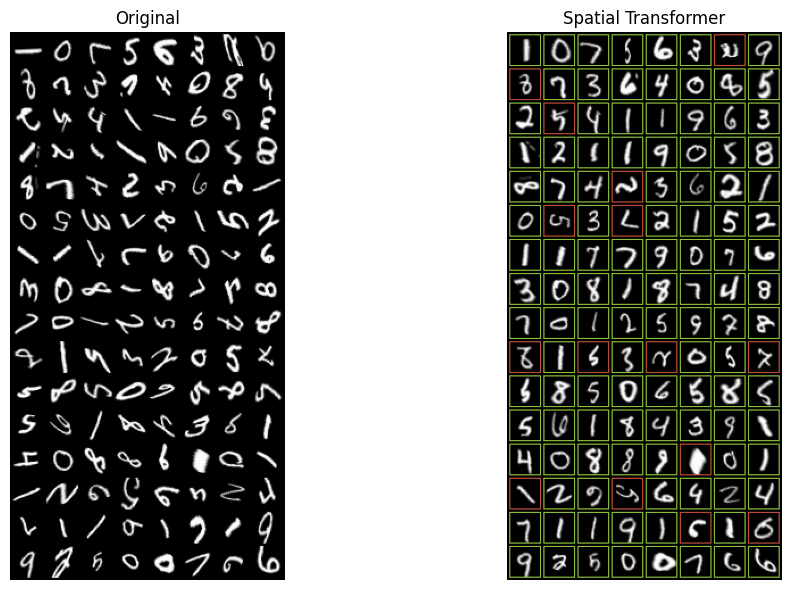

In [37]:
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(test_loader))
    data, target = data.cuda(), target.cuda()

    # 2. Apply spatial transformer
    transformed = spatial_transformer.transform_input(data)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red = torch.tensor((194, 80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:, 0, :] = color
        img[:, -1, :] = color
        img[:, :, 0] = color
        img[:, :, -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=8).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=8).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [38]:
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer(data)
        st_acc += output.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

Spatial transformer accuracy on the transformed test set: 0.8948.


In [39]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.cuda().eval()
    confs =[]
    correct =[]
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        data_transformed = spatial_transformer.transform_input(data)
        conf,output = conf_2(data_transformed)
        confs.append(conf.cpu().numpy())
        assert torch.allclose(spatial_transformer(data), output)

        same =output.argmax(dim=-1).eq(target)
        correct.append(same.cpu().numpy())
        st_acc += same.sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

Spatial transformer accuracy on the transformed test set: 0.8948.


In [40]:
spatial_transformer(data).cpu().detach().numpy()

array([[ -5.0469174 , -13.289821  ,  -1.8421446 ,  -8.207797  ,
         -0.67535025,  -2.652585  ,   7.785087  , -16.562723  ,
          4.1400895 , -13.402495  ],
       [ -5.762473  , -19.004528  ,  -7.9526343 ,  -3.3189192 ,
         -0.39561617,  -8.365452  , -18.72785   ,  -4.6248393 ,
          1.517396  ,  18.049984  ],
       [ -8.893463  , -12.276853  ,  -6.573568  ,  -3.999843  ,
          4.4287944 ,  -7.2215514 , -19.884083  ,   1.1045638 ,
          1.1192846 ,  15.044524  ],
       [ -4.7709785 ,  -6.8115964 ,  -7.764133  , -11.865894  ,
          3.2471268 ,  -2.9345477 ,  14.755418  , -17.918575  ,
         -5.124519  ,  -6.9129553 ],
       [ -9.499794  ,  -8.216266  ,  17.730648  ,  -3.2818894 ,
         -8.121922  , -14.3582945 , -15.114591  ,   2.625398  ,
          0.4044048 , -13.821098  ],
       [ -2.8479729 ,   0.07394087,  10.53682   ,  -2.3333502 ,
         -8.332782  , -11.863395  , -11.858224  ,   4.312309  ,
         -5.9222627 ,  -7.413598  ],
       [ -

In [41]:
output.cpu().detach().numpy()

array([[ -5.0469174 , -13.289821  ,  -1.8421446 ,  -8.207797  ,
         -0.67535025,  -2.652585  ,   7.785087  , -16.562723  ,
          4.1400895 , -13.402495  ],
       [ -5.762473  , -19.004528  ,  -7.9526343 ,  -3.3189192 ,
         -0.39561617,  -8.365452  , -18.72785   ,  -4.6248393 ,
          1.517396  ,  18.049984  ],
       [ -8.893463  , -12.276853  ,  -6.573568  ,  -3.999843  ,
          4.4287944 ,  -7.2215514 , -19.884083  ,   1.1045638 ,
          1.1192846 ,  15.044524  ],
       [ -4.7709785 ,  -6.8115964 ,  -7.764133  , -11.865894  ,
          3.2471268 ,  -2.9345477 ,  14.755418  , -17.918575  ,
         -5.124519  ,  -6.9129553 ],
       [ -9.499794  ,  -8.216266  ,  17.730648  ,  -3.2818894 ,
         -8.121922  , -14.3582945 , -15.114591  ,   2.625398  ,
          0.4044048 , -13.821098  ],
       [ -2.8479729 ,   0.07394087,  10.53682   ,  -2.3333502 ,
         -8.332782  , -11.863395  , -11.858224  ,   4.312309  ,
         -5.9222627 ,  -7.413598  ],
       [ -

In [42]:
correct = np.hstack(correct)
confs = np.hstack(confs)

confs_correct = confs[correct]
confs_incorrect = confs[~correct]

(array([ 3.,  1.,  3.,  1.,  3.,  3.,  1.,  7.,  8.,  5.,  7.,  6.,  7.,
         5., 12., 12., 11., 18., 13., 23., 19., 17., 21., 19., 18., 20.,
        16., 21., 19., 17., 21., 16., 28., 26., 13., 13., 15.,  8.,  9.,
        13.,  8.,  3.,  3.,  4.,  3.,  1.,  2.,  2.,  0.,  2.]),
 array([0.80792403, 0.8115561 , 0.81518823, 0.8188203 , 0.82245243,
        0.82608449, 0.82971662, 0.83334869, 0.83698082, 0.84061289,
        0.84424502, 0.84787709, 0.85150921, 0.85514128, 0.85877335,
        0.86240548, 0.86603755, 0.86966968, 0.87330174, 0.87693387,
        0.88056594, 0.88419807, 0.88783014, 0.89146227, 0.89509434,
        0.89872646, 0.90235853, 0.9059906 , 0.90962273, 0.9132548 ,
        0.91688693, 0.92051899, 0.92415112, 0.92778319, 0.93141532,
        0.93504739, 0.93867952, 0.94231158, 0.94594365, 0.94957578,
        0.95320785, 0.95683998, 0.96047205, 0.96410418, 0.96773624,
        0.97136837, 0.97500044, 0.97863257, 0.98226464, 0.98589677,
        0.98952883]),
 <BarContainer

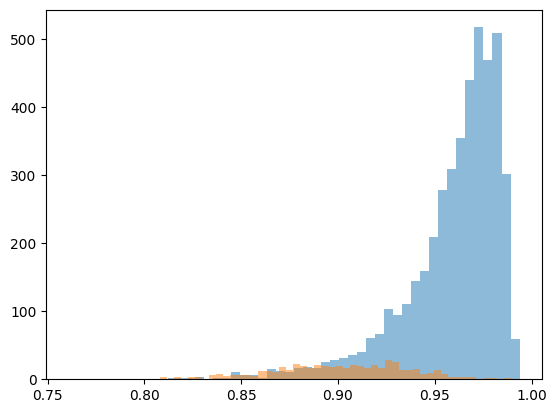

In [43]:
plt.hist(confs_correct, bins=50, alpha=0.5, label='Correct')
plt.hist(confs_incorrect, bins=50, alpha=0.5, label='Incorrect')

In [44]:
# Evaluate both models on the transformed test set
conf_search = []
correct_search = []
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        best_param,best_error,best_class = di.optimize(problem_unguided, data.cuda())
        conf_search.append(-best_error.cpu().numpy())
        same =best_class.squeeze(-1).eq(target)
        correct_search.append(same.cpu().numpy())
        st_acc += same.sum().item()
    st_acc /= len(dataset_test)
    print(f'Optimization accuracy on the transformed test set: {st_acc}.')

Optimization accuracy on the transformed test set: 0.9484.


In [45]:
conf_search = np.hstack(conf_search)
correct_search = np.hstack(correct_search)
conf_search_correct = conf_search[correct_search]
conf_search_incorrect = conf_search[~correct_search]

(array([ 3.,  1.,  3.,  1.,  3.,  3.,  1.,  7.,  8.,  5.,  7.,  6.,  7.,
         5., 12., 12., 11., 18., 13., 23., 19., 17., 21., 19., 18., 20.,
        16., 21., 19., 17., 21., 16., 28., 26., 13., 13., 15.,  8.,  9.,
        13.,  8.,  3.,  3.,  4.,  3.,  1.,  2.,  2.,  0.,  2.]),
 array([0.80792403, 0.8115561 , 0.81518823, 0.8188203 , 0.82245243,
        0.82608449, 0.82971662, 0.83334869, 0.83698082, 0.84061289,
        0.84424502, 0.84787709, 0.85150921, 0.85514128, 0.85877335,
        0.86240548, 0.86603755, 0.86966968, 0.87330174, 0.87693387,
        0.88056594, 0.88419807, 0.88783014, 0.89146227, 0.89509434,
        0.89872646, 0.90235853, 0.9059906 , 0.90962273, 0.9132548 ,
        0.91688693, 0.92051899, 0.92415112, 0.92778319, 0.93141532,
        0.93504739, 0.93867952, 0.94231158, 0.94594365, 0.94957578,
        0.95320785, 0.95683998, 0.96047205, 0.96410418, 0.96773624,
        0.97136837, 0.97500044, 0.97863257, 0.98226464, 0.98589677,
        0.98952883]),
 <BarContainer

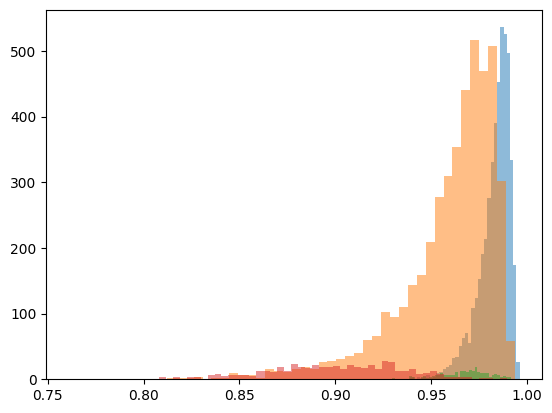

In [46]:
plt.hist(conf_search_correct, bins=50, alpha=0.5, label='Correct')
plt.hist(confs_correct, bins=50, alpha=0.5, label='Correct Non Search')
plt.hist(conf_search_incorrect, bins=50, alpha=0.5, label='Incorrect')
plt.hist(confs_incorrect, bins=50, alpha=0.5, label='Incorrect Non Search')

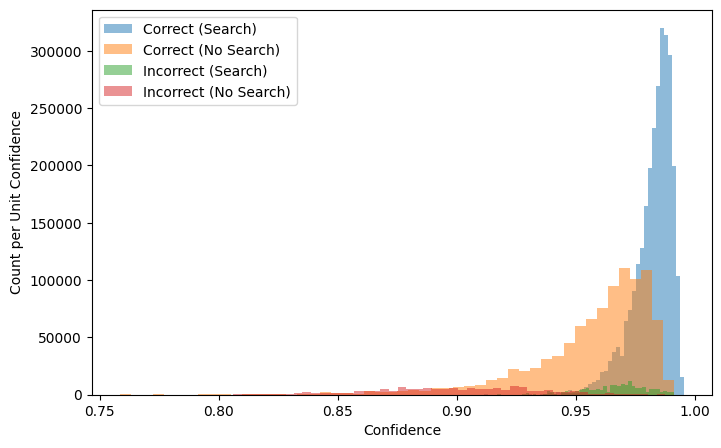

In [61]:
def histogram_with_absolute_area(ax, data, bins, **bar_kwargs):
    # 1) Compute raw counts and bin edges
    counts, edges = np.histogram(data, bins=bins)
    # 2) Bin widths
    widths = np.diff(edges)
    # 3) Heights so that height*width = count
    heights = counts / widths
    # 4) Draw a bar chart
    ax.bar(edges[:-1], heights, width=widths, **bar_kwargs)

fig, ax = plt.subplots(figsize=(8, 5))

histogram_with_absolute_area(
    ax,
    conf_search_correct,
    bins=50,
    alpha=0.5,
    label='Correct (Search)',
    color='C0'
)

histogram_with_absolute_area(
    ax,
    confs_correct,
    bins=50,
    alpha=0.5,
    label='Correct (No Search)',
    color='C1'
)

histogram_with_absolute_area(
    ax,
    conf_search_incorrect,
    bins=50,
    alpha=0.5,
    label='Incorrect (Search)',
    color='C2'
)

histogram_with_absolute_area(
    ax,
    confs_incorrect,
    bins=50,
    alpha=0.5,
    label='Incorrect (No Search)',
    color='C3'
)

ax.set_xlabel("Confidence")
ax.set_ylabel("Count per Unit Confidence")
ax.legend()
plt.show()

In [47]:
def find_optimal_threshold(correct1, correct2, confidence1, cost_classifier2=0.0):
    thresholds = np.linspace(0, 1, 1000)
    best_acc = 0
    best_thresh = 0
    best_usage = 0

    for t in thresholds:
        use_classifier1 = confidence1 >= t
        use_classifier2 = ~use_classifier1

        correct = (use_classifier1 & correct1) | (use_classifier2 & correct2)
        accuracy = np.mean(correct) - cost_classifier2 * np.mean(use_classifier2)
        usage_rate = np.mean(use_classifier2)  # or use np.sum(use_classifier2) for count

        if accuracy > best_acc:
            best_acc = accuracy
            best_thresh = t
            best_usage = usage_rate

    return best_thresh, best_acc, best_usage

In [62]:
find_optimal_threshold(correct, correct_search, confs, cost_classifier2=0.01)

(0.9409409409409409, 0.9506600000000001, 0.254)

In [82]:
(confs >= 0.02).mean()

NameError: name 'confs' is not defined

In [ ]:
#now train model that uses data augmentation

In [60]:
import pytorch_lightning as pl
import os

model_path2 = f'../model/{dataset}_23_aug.pth'

model2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path2) and False:
    print(f"Loading model from {model_path2}")
    model2.load_state_dict(torch.load(model_path2))
else:
    print(f"Training model and will save to {model_path2}")
    lightning_model = Classifier(model2, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=100,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_transformed_loader,test_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path2}")


Using 16bit Automatic Mixed Precision (AMP)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | Sequential | 421 K  | train
---------------------------------------------
421 K     Trainable params
0         Non-trainable params
421 K     Total params
1.687     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Training model and will save to ../model/mnist_23_aug.pth
Epoch 99: 100%|██████████| 469/469 [00:03<00:00, 142.56it/s, v_num=178, val_loss=0.260, val_acc=0.946]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 469/469 [00:03<00:00, 141.91it/s, v_num=178, val_loss=0.260, val_acc=0.946]
Model saved to ../model/mnist_23_aug.pth


In [ ]:
#train both together
